In [18]:
from IPython.display import display, Image

from dotenv import load_dotenv
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import END, START, StateGraph, MessagesState

# .envを読み込む
load_dotenv()


True

In [19]:
tavily_search = TavilySearchResults(max_results=3)

@tool
def web_search(search_query: str) -> list[str]:
    """クエリの内容に応じて、web検索を行う関数

    Args:
        search_query: ユーザーからの検索クエリ
    Returns:
        検索結果のリスト
    """
    results = tavily_search.invoke(search_query)

    # 結果を整形
    results_formatted = []
    for result in results:
        title = result.get("title", "No Title")
        content = result.get("content", "No Content")
        results_formatted.append(f"タイトル：{title}\n\nコンテンツ：{content}")

    return results_formatted

tools = [web_search]
tools_by_name = {tool.name: tool for tool in tools}

In [20]:

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite", temperature=0)
llm_with_tools = llm.bind_tools(tools)



In [21]:
system_prompt = """
あなたは、ユーザーの旅行予定をもとに、観光計画を立案するAIエージェントです。
web検索機能を使用しながら、ユーザーの質問に答えてください。

## 注意点
- 単一のweb検索結果のみで判断せず、いろいろな視点で情報を集めてください。
"""

def node_call_llm(state: MessagesState):
    """LLMを呼び出すノード"""
    # 最初の呼び出しの場合は、system promptを追加する
    if len(state["messages"]) == 1:
        messages = [
            SystemMessage(content=system_prompt),
            state["messages"][-1],
        ]
    else:
        messages = state["messages"]

    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}


def node_route(state: MessagesState):
    """次のノードをルーティングするノード"""
    if len(state["messages"]) > 6:
        return END

    last_message = state["messages"][-1]
    if getattr(last_message, "tool_calls", None):
        return "tools"

    return END


def node_tools(state: MessagesState):
    """ツール呼び出しを実行するノード"""
    last_message = state["messages"][-1]

    tool_messages = []
    for tool_call in getattr(last_message, "tool_calls", []):
        tool_name = tool_call.get("name")
        tool = tools_by_name.get(tool_name)
        if tool is None:
            continue

        args = tool_call.get("args", {}) or {}
        tool_result = tool.invoke(args)

        tool_messages.append(
            ToolMessage(
                content=str(tool_result),
                name=tool_name,
                tool_call_id=tool_call["id"],
            )
        )

    return {"messages": tool_messages}


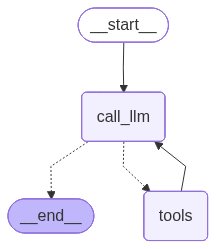

In [27]:
builder = StateGraph(MessagesState)

builder.add_node("call_llm", node_call_llm)
builder.add_node("tools", node_tools)

builder.add_edge(START, "call_llm")
builder.add_conditional_edges(
    "call_llm",
    node_route,
    {"tools": "tools", END: END},
)
builder.add_edge("tools", "call_llm")

react_agent = builder.compile()

display(Image(react_agent.get_graph().draw_mermaid_png()))

In [32]:
messages = [HumanMessage(content="4月頭の奄美大島の三泊旅行に行きます。おすすめのご飯、自然などをしらべて、それらを味わえる1日ごとの旅行計画を作ってください！")]
response = react_agent.invoke({"messages": messages})

In [33]:
response["messages"][-1].pretty_print()

================================== Ai Message ==================================

4月頭の奄美大島旅行、楽しみですね！温暖な気候で自然を満喫できるベストシーズンです。以下に、おすすめのご飯、自然、そしてそれらを味わえる1日ごとの旅行計画をご提案します。

**奄美大島の4月について**

*   **気候:** 平均気温は約20〜23℃で、日中は半袖でも過ごせる暖かさですが、朝晩は肌寒く感じることもあります。薄手の羽織りものやストールがあると便利です。
*   **服装:** Tシャツ、長袖の羽織り、スニーカーが基本。雨具（折りたたみ傘や撥水ジャケット）も忘れずに。日差しが強くなるので、帽子、サングラス、日焼け止めも必須です。
*   **海:** 海開きは3月ですが、4月は水温が21℃前後になるため、ウェットスーツを着用すればシュノーケリングやダイビングが楽しめます。

**おすすめのご飯**

*   **鶏飯（けいはん）:** 奄美のソウルフード。ご飯に具材を乗せ、鶏がらスープをかけていただきます。
*   **油そうめん:** そうめん（またはうどん）に煮干し、人参、ニラなどを入れたあっさりとした一品。
*   **島料理:** 新鮮な魚介類を使った刺身や、豚の角煮、ヤギ汁（挑戦する価値あり！）、もずく天ぷらなど。
*   **黒糖焼酎:** 奄美ならではのお酒。様々な種類の蔵元があるので、飲み比べてみるのも楽しいでしょう。
*   **海鮮料理:** 新鮮な魚介類が豊富。特に「あまみの魚たち」や「島の居酒屋むちゃかな」などがおすすめです。
*   **郷土料理:** 「喜多八」や「鳥しん」などで、奄美の伝統的な味を堪能できます。

**おすすめの自然・アクティビティ**

*   **マングローブ:** 黒潮の森マングローブパークでのカヌー体験は、神秘的な自然を感じられます。
*   **滝:** フナンギョの滝、タンギョの滝、アランガチの滝など、迫力ある滝や癒される滝があります。
*   **ビーチ:** 土盛海岸、倉崎海岸、実久海岸など、美しいビーチがたくさんあります。シュノーケリングやダイビングも楽しめます。
*   **金作原原生林:** 手付かずの亜熱帯広葉樹林を散

In [34]:
for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

4月頭の奄美大島の三泊旅行に行きます。おすすめのご飯、自然などをしらべて、それらを味わえる1日ごとの旅行計画を作ってください！
================================== Ai Message ==================================

かしこまりました。奄美大島への旅行、楽しみですね！4月頭の気候やイベント情報も考慮しながら、おすすめのご飯と自然を満喫できる3泊4日の旅行プランを作成します。

まずは、奄美大島の魅力についていくつか調べてみましょう。
Tool Calls:
  web_search (0c4eb24d-a1e7-48b0-8c2d-11a6f8306dca)
 Call ID: 0c4eb24d-a1e7-48b0-8c2d-11a6f8306dca
  Args:
    search_query: 奄美大島 4月 おすすめ ご飯 自然
  web_search (b087f8d1-33fb-4647-ac7a-c035b0c5d8ad)
 Call ID: b087f8d1-33fb-4647-ac7a-c035b0c5d8ad
  Args:
    search_query: 奄美大島 4月 イベント
  web_search (5735b2c2-beee-4c8f-83ff-8b6db80712e6)
 Call ID: 5735b2c2-beee-4c8f-83ff-8b6db80712e6
  Args:
    search_query: 奄美大島 おすすめ 海鮮料理
  web_search (00dcff10-f30a-4154-84da-ebcc3bbc0176)
 Call ID: 00dcff10-f30a-4154-84da-ebcc3bbc0176
  Args:
    search_query: 奄美大島 おすすめ 郷土料理
  web_search (6cfb9fee-b3c7-47ca-8bb6-dccd35c9e4a6)
 Call ID: 6cfb9fee-b3c7-47ca-8bb6-dc